# YZM0206 Proje - Baseline CNN Modeli

Bu notebookta EuroSAT RGB veri seti üzerinde transfer learning kullanılmadan aynı baseline CNN modelinin b versiyonu eğitilecektir. Ana baseline ile aynı veri ayrımı ve aynı CNN mimarisi korunmuş, eğitim sırasında augmentation katmanı kullanılmıştır.

Bu aşamada yapılan işlemler:

1. Veri hazırlama notebookunda oluşturulan train / validation / test splitinin okunması
2. Eğitim sırasında görüntülerin 224x224 boyutuna getirilmesi ve normalizasyon uygulanması
3. Basit CNN mimarisinin kurulması
4. Modelin eğitim ve validation performansının izlenmesi
5. Test kümesi üzerinde final değerlendirme yapılması
6. Confusion matrix ve classification report ile sınıf bazlı performansın incelenmesi

## Kütüphaneler ve proje dizinleri

Bu bölümde model eğitimi, performans ölçümü ve görselleştirme için gerekli kütüphaneler içe aktarılmıştır. Sonuçların tekrar üretilebilir olması için seed değerleri sabitlenmiştir.

In [1]:
import json
import random
import shutil
import time
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")

try:
    import importlib
    importlib.import_module("google.colab.drive").mount("/content/drive")
except Exception:
    pass


def find_project_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for root in [Path("/content") / "drive" / "MyDrive", Path("/content") / "drive" / "Shareddrives"]:
        project_candidate = root / "YZM0206 Proje"
        if project_candidate.exists():
            candidates.append(project_candidate)

    for candidate in candidates:
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError("Proje klasörü bulunamadı. Notebook proje klasörü içinden çalıştırılmalıdır.")


def count_images(directory):
    if not directory.exists():
        return 0
    return sum(1 for _ in directory.glob("*/*.jpg"))


def split_zip_counts(zip_path):
    counts = {"train": 0, "valid": 0, "test": 0}

    if not zip_path.exists():
        return counts

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        for name in zip_ref.namelist():
            parts = name.split("/")
            if len(parts) == 3 and parts[0] in counts and name.lower().endswith(".jpg"):
                counts[parts[0]] += 1

    return counts


def prepare_local_split_from_zip():
    if not SPLIT_ZIP_PATH.exists():
        raise FileNotFoundError("Split zip dosyası bulunamadı. Önce 01_dataset_preparation.ipynb çalıştırılmalıdır.")

    expected = split_zip_counts(SPLIT_ZIP_PATH)

    if sum(expected.values()) != 27000:
        raise RuntimeError("Split zip dosyası beklenen 27000 görüntüyü içermiyor.")

    split_ready = all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items())

    if split_ready:
        return

    if SPLIT_ROOT.exists():
        shutil.rmtree(SPLIT_ROOT)

    SPLIT_ROOT.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(SPLIT_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(SPLIT_ROOT)

    if not all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items()):
        raise RuntimeError("Split zip dosyası çalışma alanına eksik çıkarıldı.")


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_ZIP_PATH = PROCESSED_DIR / "eurosat_split_seed42.zip"

LOCAL_WORK_DIR = Path("/content/eurosat_work") if Path("/content").exists() else DATA_DIR / "local_work"
SPLIT_ROOT = LOCAL_WORK_DIR / "split_seed42"
SPLIT_DIRS = {
    "train": SPLIT_ROOT / "train",
    "valid": SPLIT_ROOT / "valid",
    "test": SPLIT_ROOT / "test",
}
TRAIN_DIR = SPLIT_DIRS["train"]
VALID_DIR = SPLIT_DIRS["valid"]
TEST_DIR = SPLIT_DIRS["test"]

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in [FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

prepare_local_split_from_zip()

print("Hazırlık tamamlandı.")
print("TensorFlow:", tf.__version__)
print("Train görüntü sayısı:", count_images(TRAIN_DIR))
print("Validation görüntü sayısı:", count_images(VALID_DIR))
print("Test görüntü sayısı:", count_images(TEST_DIR))

Mounted at /content/drive
Hazırlık tamamlandı.
TensorFlow: 2.20.0
Train görüntü sayısı: 18900
Validation görüntü sayısı: 4050
Test görüntü sayısı: 4050


## Veri kümelerini yükleme

Bu bölümde veri hazırlama notebookunda oluşturulan `eurosat_split_seed42.zip` dosyası açılmış ve model eğitimi için aynı `train`, `valid` ve `test` kümeleri kullanılmıştır. Bu nedenle baseline CNN ile transfer learning modelleri aynı split üzerinde karşılaştırılacaktır.

Görüntüler model girişine uygun olarak `224x224` boyutuna getirilmiştir. Bu işlem ham dosyaları değiştirmez; yalnızca eğitim sırasında modele verilen tensörlerin boyutunu standartlaştırır.

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_data.class_names
num_classes = len(class_names)

print("Sınıf sayısı:", num_classes)
print(class_names)

Found 18900 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Sınıf sayısı: 10
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Normalizasyon

Baseline CNN modelinde piksel değerleri 0-255 aralığından 0-1 aralığına çevrilmiştir. Bu işlem modelin daha stabil öğrenmesine yardımcı olur.

In [3]:
def normalize_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_data = train_data.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
valid_data = valid_data.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_data = test_data.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Veri pipeline hazır.")

Veri pipeline hazır.


## Augmentation

Bu b versiyonunda, ana baseline ile aynı mimari korunurken eğitim sırasında küçük geometrik dönüşümler uygulanmıştır.

In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.10, 0.10),
], name="data_augmentation")

print("Augmentation katmanı hazır.")

Augmentation katmanı hazır.


## Baseline CNN mimarisi

Bu model herhangi bir hazır ağırlık kullanmadan sıfırdan eğitilecektir. Ana baseline ile karşılaştırmanın adil olması için convolution, pooling, dense ve dropout katmanları aynı tutulmuştur.

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(num_classes, activation="softmax")
], name="baseline_cnn_b")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "baseline_cnn_b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

## Model eğitimi

Model, validation accuracy değeri izlenerek eğitilmiştir. `EarlyStopping` overfitting riskini azaltmak için kullanılmıştır. En iyi validation sonucunu veren model ağırlıkları `models/baseline_cnn_b_best.keras` dosyasına kaydedilecektir.

In [6]:
EPOCHS = 20

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "baseline_cnn_b_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Eğitim süresi (sn):", round(training_time, 2))

Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2548 - loss: 1.9068
Epoch 1: val_accuracy improved from None to 0.52716, saving model to /content/drive/MyDrive/YZM0206 Proje/models/baseline_cnn_b_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/baseline_cnn_b_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.3255 - loss: 1.7279 - val_accuracy: 0.5272 - val_loss: 1.3945
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4871 - loss: 1.4059
Epoch 2: val_accuracy improved from 0.52716 to 0.62049, saving model to /content/drive/MyDrive/YZM0206 Proje/models/baseline_cnn_b_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/baseline_cnn_b_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.5219 - loss: 1.3412 - val_accuracy: 0.6205 - val_loss: 1.0820
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5931 - loss: 1.1573
Epoch 3: v

## Eğitim grafikleri

Accuracy ve loss grafikleri, modelin eğitim sırasında öğrenip öğrenmediğini ve validation setinde overfitting belirtisi olup olmadığını görmek için çizilmiştir.

In [7]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.325503,1.727943,0.527160,1.394544
1,0.521852,1.341223,0.620494,1.081965
2,0.602011,1.137074,0.662469,0.983056
3,0.631270,1.045745,0.677284,0.907237
4,0.655979,0.984210,0.671852,0.887040
5,0.665608,0.945073,0.687654,0.871196
6,0.689788,0.875372,0.733333,0.751531
7,0.711693,0.812469,0.751358,0.684362
8,0.721534,0.781329,0.754321,0.679850
9,0.732381,0.746419,0.760000,0.668257


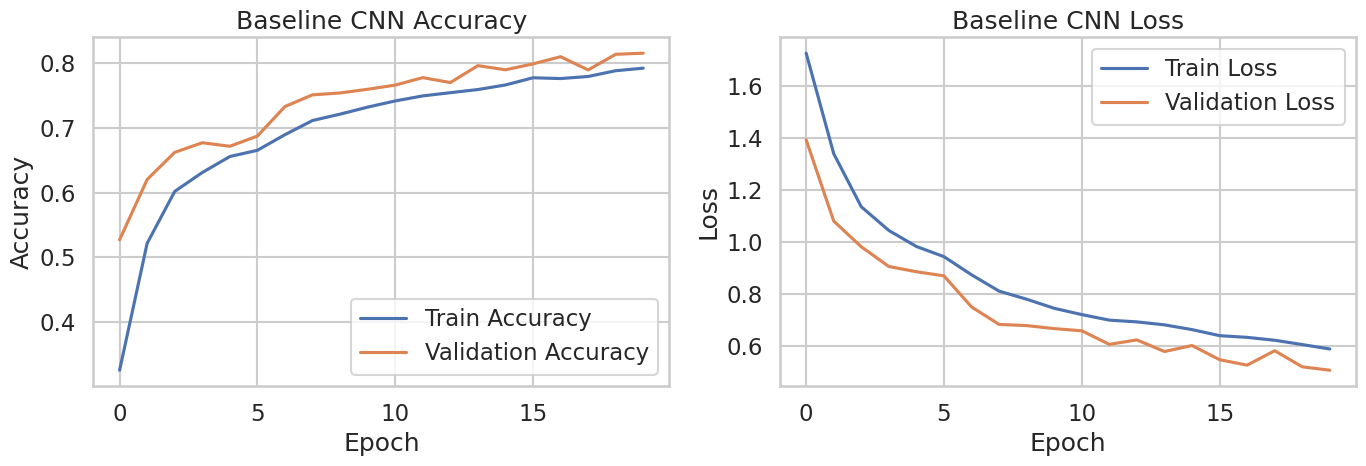

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_cnn_b_accuracy_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Eğitim eğrilerinin yorumu

Bu model de 20 epoch boyunca eğitilmiştir. İlk epochta train accuracy 0.3255, validation accuracy ise 0.5272 olarak başlamıştır. Son epochta train accuracy 0.7926, validation accuracy 0.8158 değerine ulaşmıştır.

En iyi validation accuracy değeri 0.8158 olarak elde edilmiştir. Ana baseline CNN modelinde en iyi validation accuracy 0.8133 idi. Bu nedenle b versiyonunda validation tarafında küçük ama ölçülebilir bir iyileşme vardır.

Loss değeri 1.7279 seviyesinden 0.5898 seviyesine düşmüştür. Augmentation kullanılmasına rağmen train accuracy ana baseline ile çok benzer kalmıştır. Bu durum modelin daha zorlaştırılmış eğitim örnekleri görmesine rağmen genel öğrenme kapasitesini koruduğunu göstermektedir.

## Test kümesi değerlendirmesi

Test kümesi eğitim sırasında kullanılmamıştır. Bu nedenle modelin daha tarafsız performansını görmek için final değerlendirme bu küme üzerinde yapılmıştır.

In [9]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test loss değeri:", test_loss)
print("Test accuracy değeri:", test_accuracy)

127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8279 - loss: 0.4877
Test loss değeri: 0.4877189099788666
Test accuracy değeri: 0.8279012441635132


## Test sonucu yorumu

Test kümesi üzerinde bu model 0.8279 accuracy ve 0.4877 loss değerine ulaşmıştır. Ana baseline CNN modelinin test accuracy değeri 0.8207, test loss değeri ise 0.5135 idi.

Bu sonuç augmentation kullanılan b versiyonunun test accuracy değerini yaklaşık 0.0072, yani 0.72 yüzde puan artırdığını göstermektedir. Test loss değerinin de 0.5135'ten 0.4877'ye düşmesi, modelin tahminlerinde biraz daha güvenli ve dengeli hale geldiğini düşündürmektedir.

## Tahminlerin alınması

Confusion matrix ve classification report hesaplamak için test kümesindeki gerçek sınıflar ve model tahminleri ayrı listelerde toplanmıştır.

In [10]:
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Tahmin sayısı:", len(y_pred))

Tahmin sayısı: 4050


## Classification report

Accuracy tek başına modelin sınıf bazlı davranışını açıklamak için yeterli değildir. Bu nedenle precision, recall ve F1-score değerleri de incelenmiştir.

In [11]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(REPORTS_DIR / "baseline_cnn_b_classification_report.csv", encoding="utf-8-sig")
report_df

,precision,recall,f1-score,support
AnnualCrop,0.854260,0.846667,0.850446,450.000000
Forest,0.855397,0.933333,0.892667,450.000000
HerbaceousVegetation,0.836066,0.793333,0.814139,450.000000
Highway,0.727273,0.618667,0.668588,375.000000
Industrial,0.899471,0.906667,0.903054,375.000000
Pasture,0.796923,0.863333,0.828800,300.000000
PermanentCrop,0.652370,0.770667,0.706601,375.000000
Residential,0.864372,0.948889,0.904661,450.000000
River,0.823171,0.720000,0.768137,375.000000
SeaLake,0.947368,0.840000,0.890459,450.000000


## Sınıf bazlı performans yorumu

Classification report incelendiğinde en yüksek F1-score değerleri Residential (0.9047), Industrial (0.9031), Forest (0.8927) ve SeaLake (0.8905) sınıflarında elde edilmiştir. Bu sınıflar ana baseline modelde de güçlüydü; b versiyonunda özellikle Residential sınıfı daha iyi sonuç vermiştir.

En düşük F1-score değerleri Highway (0.6686), PermanentCrop (0.7066) ve River (0.7681) sınıflarında görülmektedir. Highway sınıfı hâlâ en zayıf sınıf olsa da ana baseline modeldeki 0.5989 F1-score değerine göre belirgin şekilde iyileşmiştir. River sınıfında da 0.7367'den 0.7681'e yükseliş vardır.

Buna karşılık PermanentCrop ve SeaLake sınıflarında F1-score ana baseline modeline göre biraz düşmüştür. Bu nedenle augmentation genel performansı artırmış olsa da her sınıfta eşit iyileşme sağlamamıştır.

## Confusion matrix

Confusion matrix, modelin hangi sınıfları birbiriyle karıştırdığını görmek için kullanılmıştır. Bu analiz özellikle görsel olarak benzer arazi sınıflarında önemlidir.

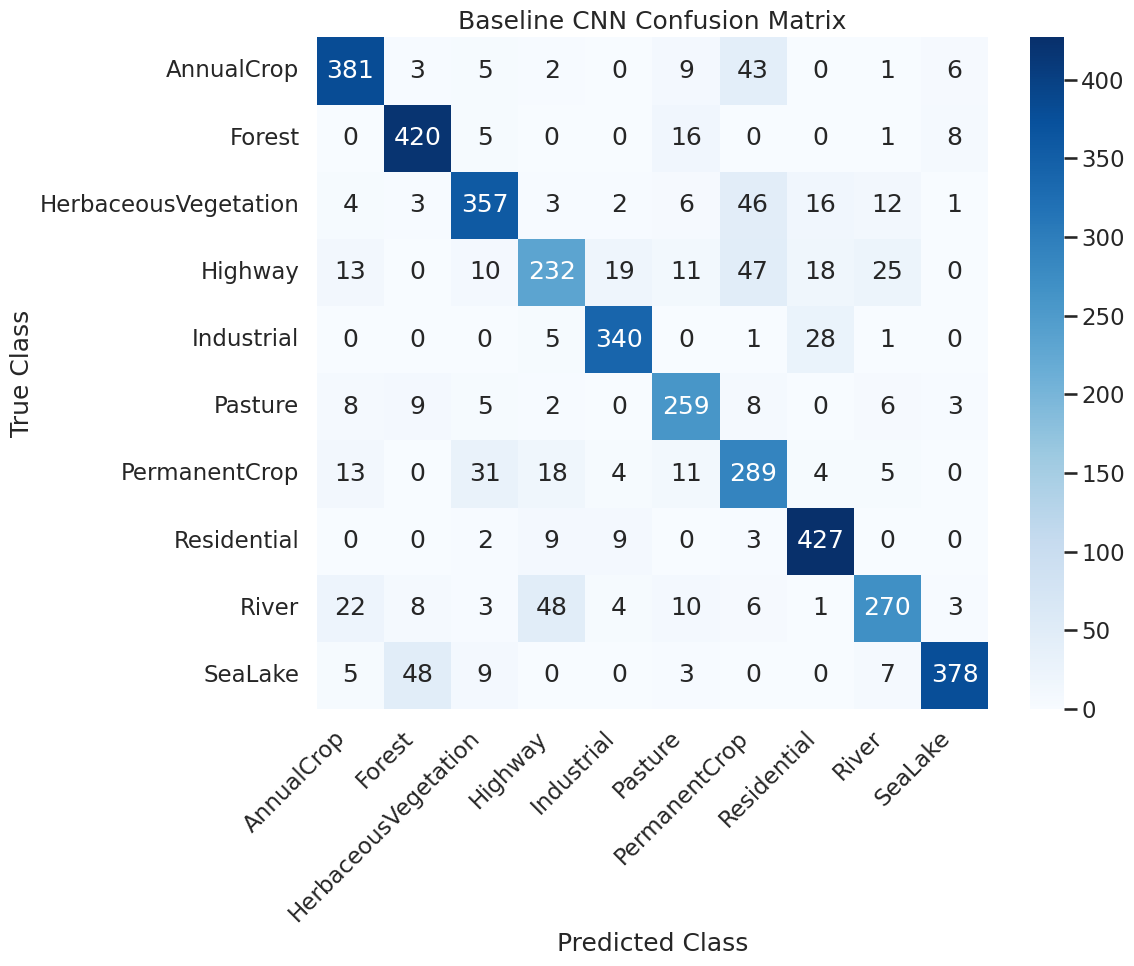

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_cnn_b_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion matrix yorumu

Confusion matrix ve classification report birlikte değerlendirildiğinde augmentation kullanılan b versiyonunun özellikle Highway ve River gibi sınıflarda ana baseline modele göre daha iyi davrandığı görülmektedir. Bu durum geometrik dönüşümlerin çizgisel yapıların farklı konum ve yönlerde tanınmasına yardımcı olmuş olabileceğini düşündürmektedir.

Ancak PermanentCrop ve SeaLake sınıflarında küçük düşüşler vardır. Bu nedenle augmentation etkisi genel olarak olumlu olsa da sınıf bazında karışık bir etki göstermiştir.

## Sonuçları kaydetme

Modelin genel performans değerleri, sınıf bazlı classification report tablosu ve eğitim geçmişi sonraki karşılaştırma notebookunda kullanılmak üzere kaydedilmiştir. Accuracy değerine ek olarak macro/weighted precision, recall, F1-score ve balanced accuracy değerleri de hesaplanmıştır.

In [13]:
summary_metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    "weighted_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
}

metrics = {
    "model": "Baseline CNN B",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "best_val_accuracy": float(max(history.history["val_accuracy"])),
    "epochs_ran": int(len(history.history["loss"])),
    "training_time_seconds": float(training_time),
    "total_params": int(model.count_params()),
    "num_classes": int(num_classes),
    "class_names": class_names,
    **summary_metrics,
}

metrics_path = REPORTS_DIR / "baseline_cnn_b_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

history_df.to_csv(REPORTS_DIR / "baseline_cnn_b_history.csv", index=False, encoding="utf-8-sig")

pd.DataFrame([metrics])

,model,test_loss,test_accuracy,best_val_accuracy,epochs_ran,training_time_seconds,total_params,num_classes,class_names,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Baseline CNN B,0.487719,0.827901,0.815802,20,715.808757,111050,10,"[AnnualCrop, Forest, HerbaceousVegetation, Hig...",0.827901,0.824156,0.825667,0.824156,0.822755,0.830443,0.827901,0.827062


## Baseline sonucu

Bu notebook sonunda transfer learning kullanılmadan baseline CNN modelinin b versiyonuna ait performans elde edilmiştir. Model 0.8279 test accuracy, 0.8228 macro F1-score ve 0.8271 weighted F1-score değerlerine ulaşmıştır.

Ana baseline CNN ile karşılaştırıldığında test accuracy yaklaşık 0.72 yüzde puan, macro F1-score ise yaklaşık 0.89 yüzde puan artmıştır. Bu fark çok büyük değildir; ancak augmentation kullanımının sade CNN üzerinde küçük bir genelleme katkısı sağladığını göstermektedir.

Final karşılaştırmada bu model ana baseline'a ek bir kontrol deneyi olarak değerlendirilecektir. Transfer learning modellerinin ise bu iki baseline sonucunun belirgin şekilde üzerine çıkması beklenmektedir.